In [1]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_523771/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m/P_INPUT/Iceland3_grid_MAT.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300
model_bgc_dia_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc_dia.202402[1-2]???????.nc"
variables=['pH_3D']
model_bgc_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc.202402[1-2]???????.nc"

target_depth_levels=[1,2,3,4,5,6,7, 8, 9, 10, 15, 20] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [3]:
from roms_tools import Grid, ROMSOutput

In [4]:
grid = Grid.from_file(
    model_grid_path
)

2026-02-13 14:24:05 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2026-02-13 14:24:05 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2026-02-13 14:24:05 - INFO - Total time: 0.004 seconds
2026-02-13 14:24:05 - INFO - ================================================================================================


In [5]:
#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)

In [6]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_dia_path,
    ],
    use_dask=True,
)

ds = roms_output.regrid(depth_levels=target_depth_levels, var_names=variables)


In [7]:
ds=ds.thin({'time': thinner}).load()

In [8]:
ds

<xarray.Dataset> Size: 39GB
Dimensions:  (time: 216, lat: 965, lon: 1929, depth: 12)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2024-02-17T02:00:00 ... 2024-02-26T01:...
  * lat      (lat) float32 4kB 64.0 64.0 64.0 64.0 64.0 ... 65.0 65.0 65.0 65.0
  * lon      (lon) float32 8kB 337.0 337.0 337.0 337.0 ... 339.0 339.0 339.0
  * depth    (depth) float32 48B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 15.0 20.0
Data variables:
    pH_3D    (time, lat, lon, depth) float64 39GB nan nan nan ... nan nan nan
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:              Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       OFF
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    regrid_method:      bilinear

In [9]:
pH_maxdepth=ds['pH_3D'].max(dim='depth', skipna=True)
pH_maxdepth

<xarray.DataArray 'pH_3D' (time: 216, lat: 965, lon: 1929)> Size: 3GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(216, 965, 1929))
Coordinates:
  * time     (time) datetime64[ns] 2kB 2024-02-17T02:00:00 ... 2024-02-26T01:...
  * lat      (lat) float32 4kB 64.0 64.0 64.0 64.0 64.0 ... 65.0 65.0 65.0 65.0
  * lon      (lon) float32 8kB 337.0 337.0 337.0 337.0 ... 339.0 339.0 339.0

In [10]:
lat0 = 64.394213   # deg N
lon0 = -21.465904  # deg E

r_min = 50    # meters
r_max = 200   # meters

import numpy as np
import xarray as xr

R = 6371000.0  # Earth radius (m)

lat = np.deg2rad(pH_maxdepth.lat)
lon = np.deg2rad(pH_maxdepth.lon)
lat0_rad = np.deg2rad(lat0)
lon0_rad = np.deg2rad(lon0)

# Haversine distance
dlat = lat - lat0_rad
dlon = lon - lon0_rad

a = np.sin(dlat / 2)**2 + np.cos(lat0_rad) * np.cos(lat) * np.sin(dlon / 2)**2
distance = 2 * R * np.arcsin(np.sqrt(a))

# Attach distance as a DataArray
distance_da = xr.DataArray(
    distance,
    coords={"lat": pH_maxdepth.lat, "lon": pH_maxdepth.lon},
    dims=("lat", "lon"),
    name="distance"
)

mask = (distance_da >= r_min) & (distance_da <= r_max)

pH_annulus_max = (
    pH_maxdepth
    .where(mask)
    .max(dim=("lat", "lon"))
)



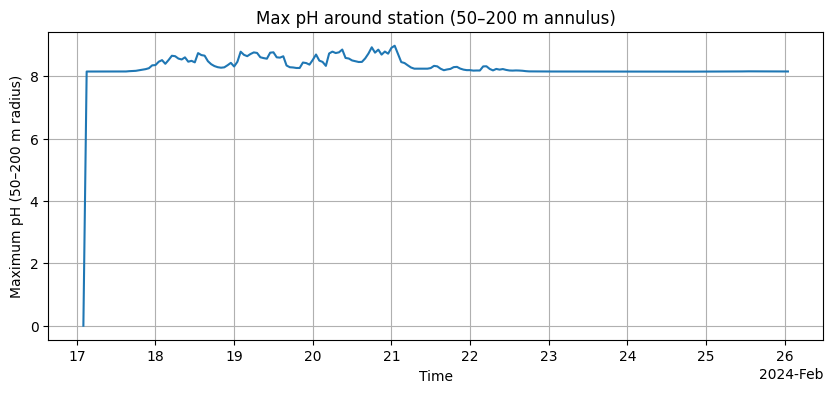

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
pH_annulus_max.plot()
plt.ylabel("Maximum pH (50–200 m radius)")
plt.title("Max pH around station (50–200 m annulus)")
plt.grid(True)
plt.show()


In [12]:
max=np.max(pH_annulus_max)
max

<xarray.DataArray 'pH_3D' ()> Size: 8B
array(8.97952453)

In [13]:
#import numpy as np
#import xarray as xr

## Start time
#t0 = np.datetime64("2024-02-17T18:00")

# Time offsets to report
#offsets = {
#    "after 15 min":   np.timedelta64(15, "m"),
#    "after 1 hr":     np.timedelta64(1, "h"),
#    "after 4 hours":  np.timedelta64(4, "h"),
#    "after 8 hours":  np.timedelta64(8, "h"),
#    "after 12 hours": np.timedelta64(12, "h"),
#    "after 24 hours": np.timedelta64(24, "h"),
#    "after 36 hours": np.timedelta64(36, "h"),
#    "after 48 hours": np.timedelta64(36, "h"),
#    "after 72 hours": np.timedelta64(36, "h"),
#    "after 96 hours": np.timedelta64(36, "h"),
#}

## Subset starting at t0
#ts = pH_annulus_max.sel(time=slice(t0, None))

## Cumulative maximum along time
#ts_cummax = xr.apply_ufunc(
#    np.maximum.accumulate,
#    ts,
#    input_core_dims=[["time"]],
#    output_core_dims=[["time"]],
#    vectorize=False,
#)


#print("Cumulative maximum pH (50–200 m radius):\n")

#for label, dt in offsets.items():
#    target_time = t0 + dt

#    val = ts_cummax.sel(time=target_time, method="nearest")
#    actual_time = np.datetime_as_string(val.time.values, unit="m")

#    print(f"{label:15s} (≤ {actual_time}) : {float(val.values):.4f}")


In [14]:
# Maximum pH at each grid cell (over time)
ph_max = ds["pH_3D"].max(dim="time", skipna=True).max(dim="depth", skipna=True)
ph_max.name = "PH_max"
ph_max.attrs["long_name"] = "Maximum pH"


In [15]:
# Land mask: 1 = land, 0 = ocean
land_mask = xr.where(np.isnan(ph_max), 1, 0)
land_mask.name = "land_mask"

In [16]:
from pyproj import Geod
import matplotlib.pyplot as plt

def add_scalebar(ax, length_km, location=(0.1, 0.05), linewidth=3):
    """
    Add a scale bar to a Cartopy map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axes
    length_km : float
        Length of scale bar in kilometers
    location : tuple
        (x_frac, y_frac) position in axes coordinates
    linewidth : int
        Line width
    """

    geod = Geod(ellps="WGS84")

    # Get current map extent in PlateCarree
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())

    # Starting point
    lon_start = lon_min + location[0] * (lon_max - lon_min)
    lat_start = lat_min + location[1] * (lat_max - lat_min)

    # Compute endpoint using geodesic
    lon_end, lat_end, _ = geod.fwd(
        lon_start, lat_start,
        az=90,              # eastward
        dist=length_km * 1000
    )

    # Draw scale bar
    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        transform=ccrs.PlateCarree(),
        color="black",
        linewidth=linewidth
    )

    # Label
    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.002,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="bottom",
        fontsize=9
    )


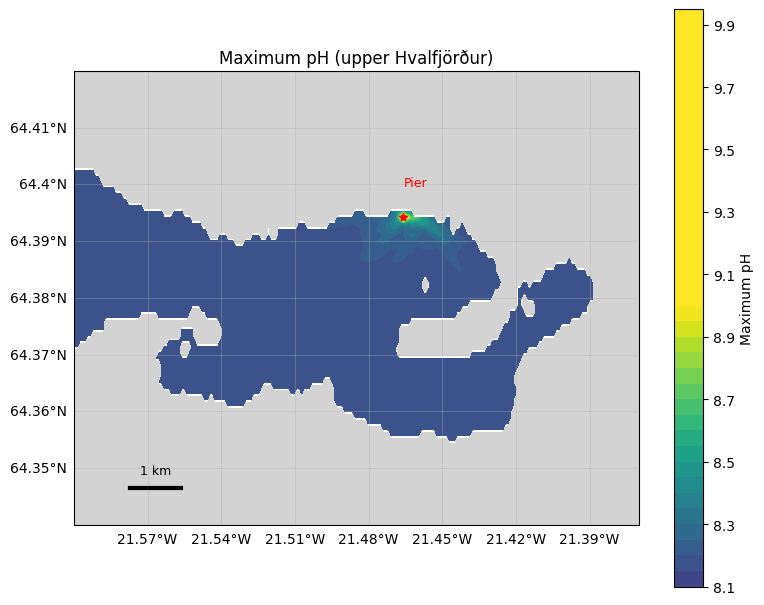

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ph_max_plot = ph_max.assign_coords(
    lon=((ph_max.lon + 180) % 360) - 180
).sortby("lon")

land_mask_plot = land_mask.assign_coords(
    lon=((land_mask.lon + 180) % 360) - 180
).sortby("lon")


extent_upper_hval = [
    -21.6,   # lon min
    -21.37,  # lon max
    64.34,   # lat min
    64.42    # lat max
]
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.Mercator())

ax.set_extent(extent_upper_hval, crs=ccrs.PlateCarree())

# --------------------------------------
# Land mask (plotted FIRST, underneath)
# --------------------------------------
ax.contourf(
    land_mask_plot.lon,
    land_mask_plot.lat,
    land_mask_plot,
    levels=[0.5, 1.5],
    colors=["lightgray"],
    transform=ccrs.PlateCarree(),
    zorder=0
)

# --------------------------------------
# Maximum pH (ocean only)
# --------------------------------------
cf = ax.contourf(
    ph_max_plot.lon,
    ph_max_plot.lat,
    ph_max_plot,
    levels=40, vmin=7.9, vmax=9,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    zorder=1
)
# Mark Pier
ax.plot(
    -21.465904, 64.394213,
    marker="*", color="red", markersize=6,
    transform=ccrs.PlateCarree()
)
ax.text(
    -21.465904, 64.394213+0.005,
    "Pier",
    color="red",
    fontsize=9,
    transform=ccrs.PlateCarree(),
    ha="left",
    va="bottom"
)


# Gridlines only (no coastlines)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(cf, ax=ax, shrink=0.75, pad=0.05)
cbar.set_label("Maximum pH")

ax.set_title("Maximum pH (upper Hvalfjörður)")

add_scalebar(
    ax,
    length_km=1,        # good for upper Hvalfjörður
    location=(0.1, 0.08)
)
plt.tight_layout()
plt.show()



In [18]:
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E

In [19]:
# Maximum pH over the spatial domain for each time step
pH_max_time = ds["pH_3D"].max(dim=("lat", "lon", "depth"), skipna=True)


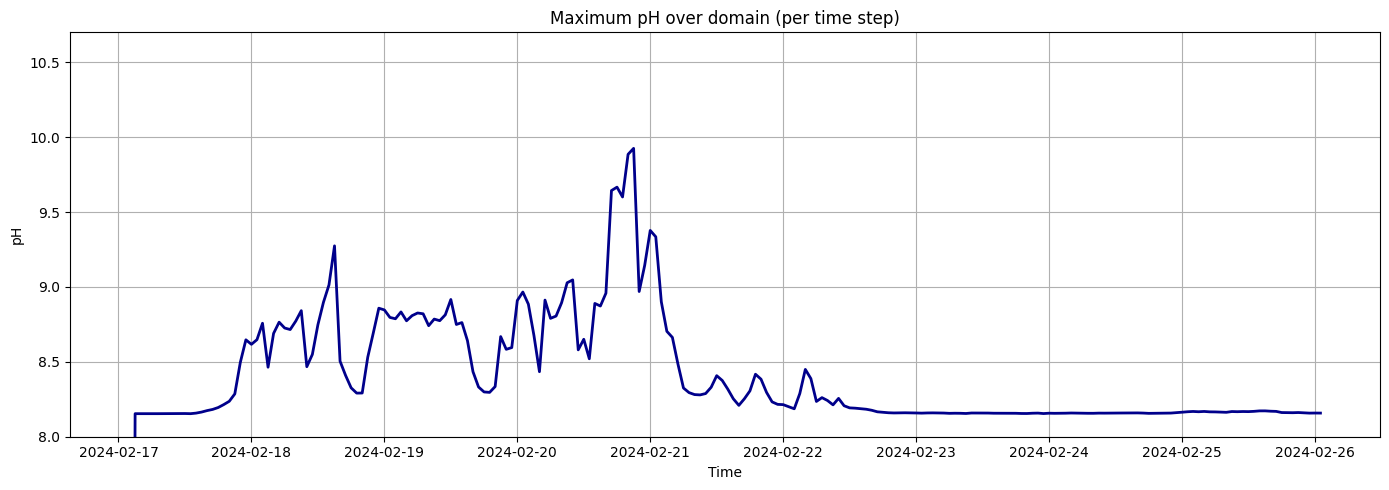

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(
    pH_max_time["time"],
    pH_max_time,
    color="darkblue",
    linewidth=2
)

plt.title("Maximum pH over domain (per time step)")
plt.xlabel("Time")
plt.ylabel("pH")
plt.grid(True)
plt.ylim(8,10.7)
plt.tight_layout()
plt.show()


In [21]:
# Maximum pH at each depth over all time and space
pH_max_profile = ds["pH_3D"].max(
    dim=("time", "lat", "lon"),
    skipna=True
)

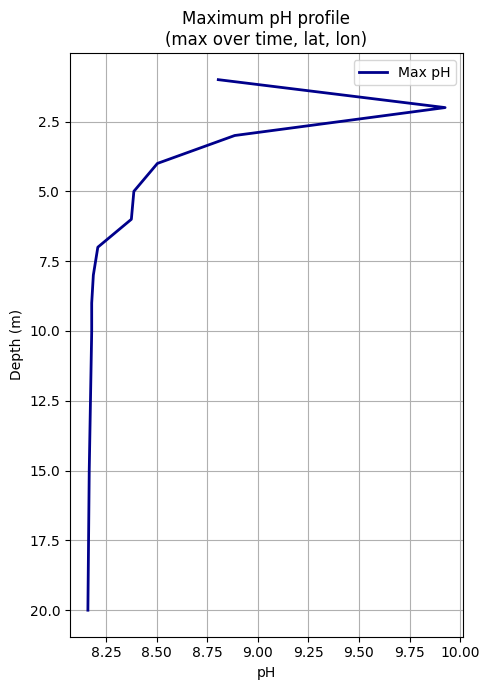

In [22]:
import matplotlib.pyplot as plt

depth = ds["depth"]

plt.figure(figsize=(5, 7))

plt.plot(
    pH_max_profile,
    depth,
    linewidth=2,
    color="darkblue",
    label="Max pH"
)

plt.gca().invert_yaxis()
plt.xlabel("pH")
plt.ylabel("Depth (m)")
plt.title("Maximum pH profile\n(max over time, lat, lon)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Load map data
ph_max_plot = ph_max_plot.load()
land_mask_plot = land_mask_plot.load()

# Load profile data
pH_max_profile = pH_max_profile.load()
depth = depth.load() if hasattr(depth, "load") else depth

# Load time series
pH_max_time = pH_max_time.load()


/tmp/ipykernel_523771/287063840.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


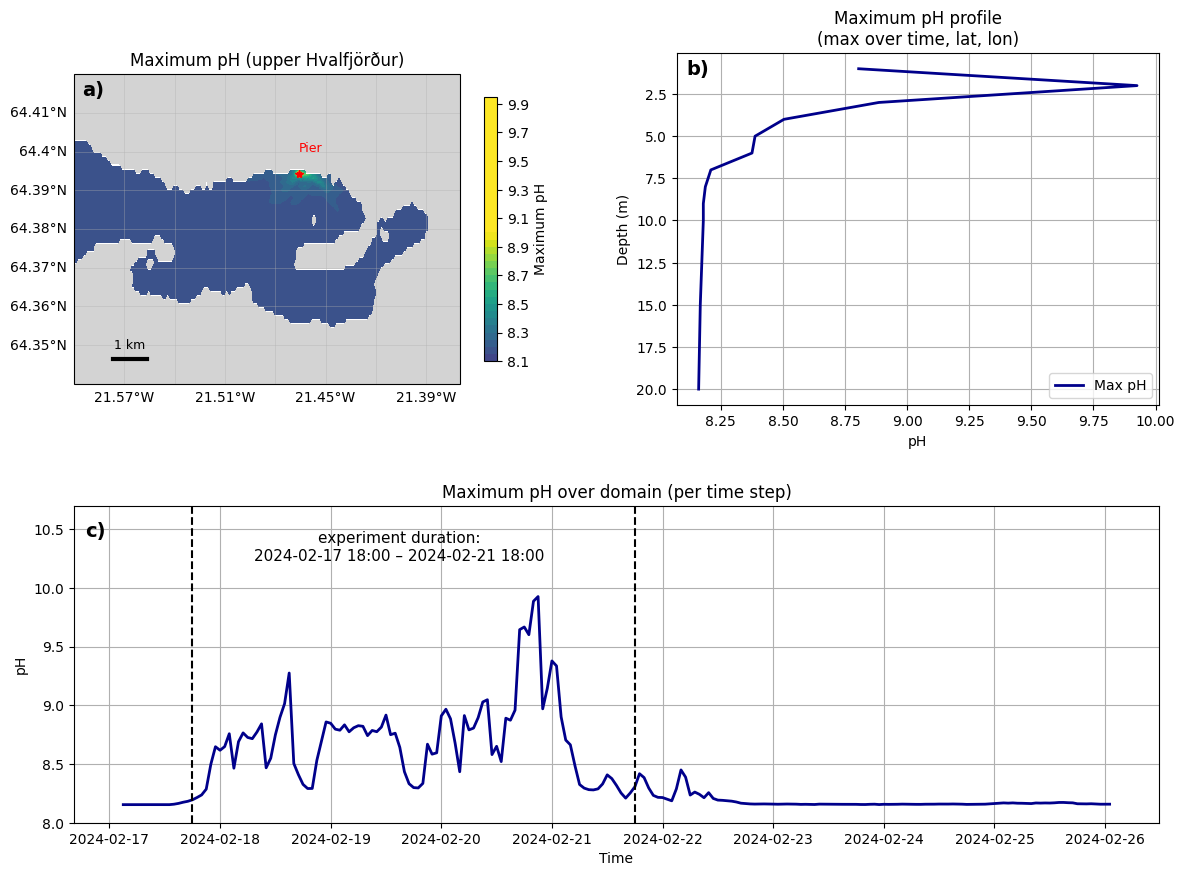

In [24]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

t_start = np.datetime64("2024-02-17T18:00:00")
t_end   = np.datetime64("2024-02-21T18:00:00")

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 0.9],
    hspace=0.3,
    wspace=0.25
)

# ==================================================
# Panel a) — Map of maximum pH
# ==================================================
ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.Mercator())
ax_map.set_extent(extent_upper_hval, crs=ccrs.PlateCarree())

# Land mask (underneath)
ax_map.contourf(
    land_mask_plot.lon,
    land_mask_plot.lat,
    land_mask_plot,
    levels=[0.5, 1.5],
    colors=["lightgray"],
    transform=ccrs.PlateCarree(),
    zorder=0
)

# Maximum pH
cf = ax_map.contourf(
    ph_max_plot.lon,
    ph_max_plot.lat,
    ph_max_plot,
    levels=40,
    vmin=7.9, vmax=9.0,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    zorder=1
)

# Pier marker
ax_map.plot(
    -21.465904, 64.394213,
    marker="*", color="red", markersize=6,
    transform=ccrs.PlateCarree()
)
ax_map.text(
    -21.465904, 64.394213 + 0.005,
    "Pier",
    color="red",
    fontsize=9,
    transform=ccrs.PlateCarree(),
    ha="left",
    va="bottom"
)

# Gridlines
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = fig.colorbar(cf, ax=ax_map, shrink=0.75, pad=0.05)
cbar.set_label("Maximum pH")

ax_map.set_title("Maximum pH (upper Hvalfjörður)")

# Panel label
ax_map.text(
    0.02, 0.98, "a)",
    transform=ax_map.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# Optional scalebar
add_scalebar(
    ax_map,
    length_km=1,
    location=(0.1, 0.08)
)

# ==================================================
# Panel b) — Depth profile
# ==================================================
ax_prof = fig.add_subplot(gs[0, 1])

ax_prof.plot(
    pH_max_profile,
    depth,
    linewidth=2,
    color="darkblue",
    label="Max pH"
)

ax_prof.invert_yaxis()
ax_prof.set_xlabel("pH")
ax_prof.set_ylabel("Depth (m)")
ax_prof.set_title("Maximum pH profile\n(max over time, lat, lon)")
ax_prof.grid(True)
ax_prof.legend()

ax_prof.text(
    0.02, 0.98, "b)",
    transform=ax_prof.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

pH_max_time_plot = pH_max_time.isel(time=slice(1, None))


# ==================================================
# Panel c) — Time series (spans both columns)
# ==================================================
ax_ts = fig.add_subplot(gs[1, :])

ax_ts.plot(
    pH_max_time_plot["time"],
    pH_max_time_plot,
    color="darkblue",
    linewidth=2
)

# Vertical lines for experiment duration
ax_ts.axvline(t_start, color="black", linestyle="--", linewidth=1.5)
ax_ts.axvline(t_end,   color="black", linestyle="--", linewidth=1.5)

# Label for experiment duration
ax_ts.text(
    0.3, 0.92,
    "experiment duration:\n2024-02-17 18:00 – 2024-02-21 18:00",
    transform=ax_ts.transAxes,
    ha="center",
    va="top",
    fontsize=11
)

ax_ts.set_title("Maximum pH over domain (per time step)")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("pH")
ax_ts.grid(True)
ax_ts.set_ylim(8, 10.7)

# Panel label
ax_ts.text(
    0.01, 0.95, "c)",
    transform=ax_ts.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)


plt.tight_layout()
plt.show()


In [25]:
cstar_output = ROMSOutput(
    grid=grid,
    path=[
        "/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/*cstar*.??????????????.nc"
    ],
    use_dask=True,
)

2026-02-13 14:30:06 - INFO - Max absolute difference between flux-based and DIC-based uptake efficiency: 2.030e+11


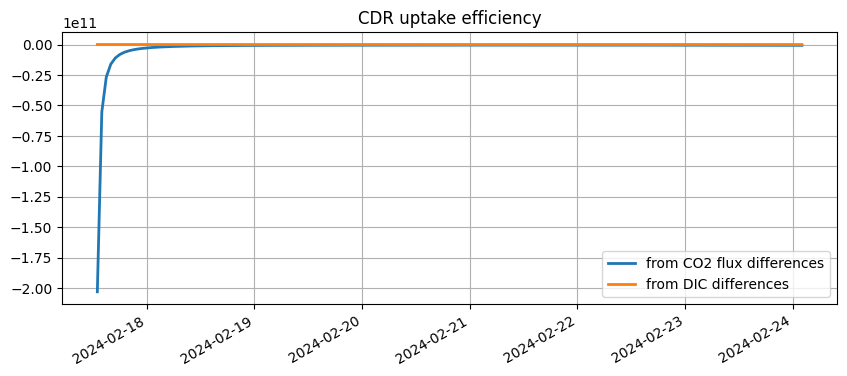

In [26]:
cstar_output.cdr_metrics()

In [28]:
cstar_output.ds

<xarray.Dataset> Size: 321GB
Dimensions:         (time: 168, eta_rho: 386, xi_rho: 642, s_rho: 60)
Coordinates:
  * time            (time) datetime64[ns] 1kB 2024-02-17T03:00:00 ... 2024-02...
    lon_rho         (eta_rho, xi_rho) float64 2MB 338.0 338.0 ... 338.7 338.7
    lat_rho         (eta_rho, xi_rho) float64 2MB 64.24 64.24 ... 64.41 64.41
Dimensions without coordinates: eta_rho, xi_rho, s_rho
Data variables: (12/23)
    ocean_time      (time) float64 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    zeta            (time, eta_rho, xi_rho) float64 333MB dask.array<chunksize=(1, 386, 642), meta=np.ndarray>
    temp            (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    salt            (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    ALK             (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    DIC             (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    ...              ...
    ALK_ALT_source  (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    DIC_source      (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    DIC_ALT_source  (time, s_rho, eta_rho, xi_rho) float64 20GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    avg_begin_time  (time) float64 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    avg_end_time    (time) float64 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    mask_rho        (eta_rho, xi_rho) float64 2MB ...
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:              Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       # of constituents:10 , real , tidalpotential
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    averaging:          All variables are averaged in time

In [25]:
ds_dicflux = roms_output.regrid(depth_levels=target_depth_levels, var_names=['FG_CO2','FG_ALT_CO2'])

In [26]:
ds_dicflux=ds_dicflux.thin({'time': thinner}).load()

In [27]:
FCO2_anom = ds_dicflux["FG_CO2"] - ds_dicflux["FG_ALT_CO2"]
R = 6371e3  # Earth radius [m]

lat = np.deg2rad(ds_dicflux.lat)
lon = np.deg2rad(ds_dicflux.lon)

dlat = float(np.abs(lat[1] - lat[0]))
dlon = float(np.abs(lon[1] - lon[0]))

cell_area = (
    R**2
    * dlat
    * dlon
    * np.cos(lat)
)

area = xr.DataArray(
    cell_area,
    coords={"lat": ds_dicflux.lat},
    dims=("lat",)
).broadcast_like(FCO2_anom.isel(time=0))

FCO2_area_int = (FCO2_anom * area).sum(
    dim=("lat", "lon"),
    skipna=True
)

# Time step in seconds
dt = (
    FCO2_area_int.time.diff("time")
    .astype("timedelta64[s]")
    .astype(float)
)

# Align dt with flux (drop first time)
FCO2_flux_trim = FCO2_area_int.isel(time=slice(1, None))

# Time-integrated uptake
FCO2_time_area_int = (FCO2_flux_trim * dt).cumsum("time")



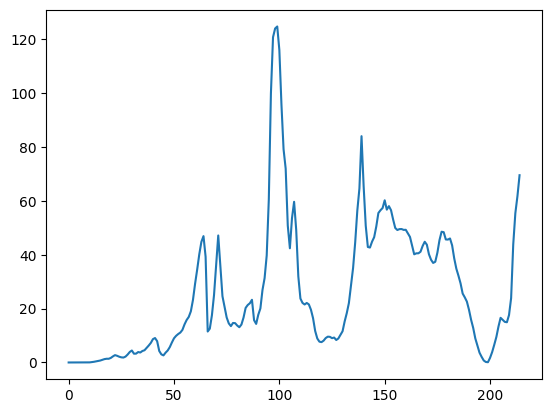

In [48]:
plt.plot(FCO2_flux_trim )

In [29]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_path,
    ],
    use_dask=True,
)

ds_alk = roms_output.regrid(depth_levels=target_depth_levels, var_names=["ALK", "ALK_ALT_CO2"])
ds_dic = roms_output.regrid(depth_levels=target_depth_levels, var_names=["DIC", "DIC_ALT_CO2"])




In [30]:
ds_alk=ds_alk.sel(
    lon=slice(-21.9+360, -21.37+360),
    lat=slice(64, 64.42)
    ).load()

In [31]:
#ds_dic.load()

In [32]:
ALK_anom = ds_alk["ALK"] - ds_alk["ALK_ALT_CO2"]

depth = ds_alk.depth

# Layer thickness (m)
dz = depth.diff("depth")

# Pad to match depth dimension length
dz = xr.concat(
    [dz.isel(depth=0), dz],
    dim="depth"
)

dz = dz.assign_coords(depth=depth)
volume = area * dz

ALK_vol_int = (ALK_anom * volume).sum(
    dim=("lat", "lon", "depth"),
    skipna=True
)


In [33]:
ratio=FCO2_time_area_int/ALK_vol_int

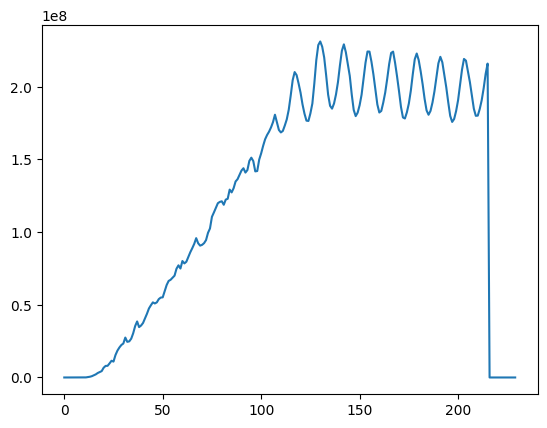

In [49]:
plt.plot(ALK_vol_int)

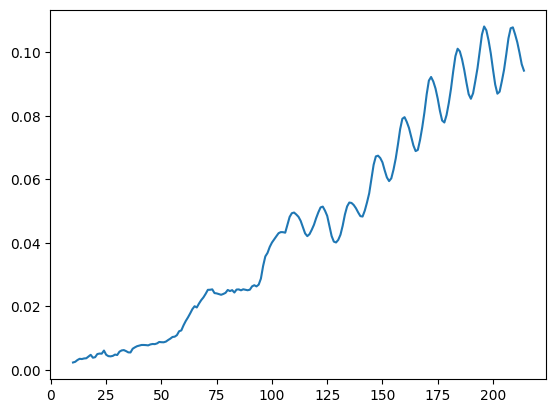

In [39]:
plt.plot(ratio)

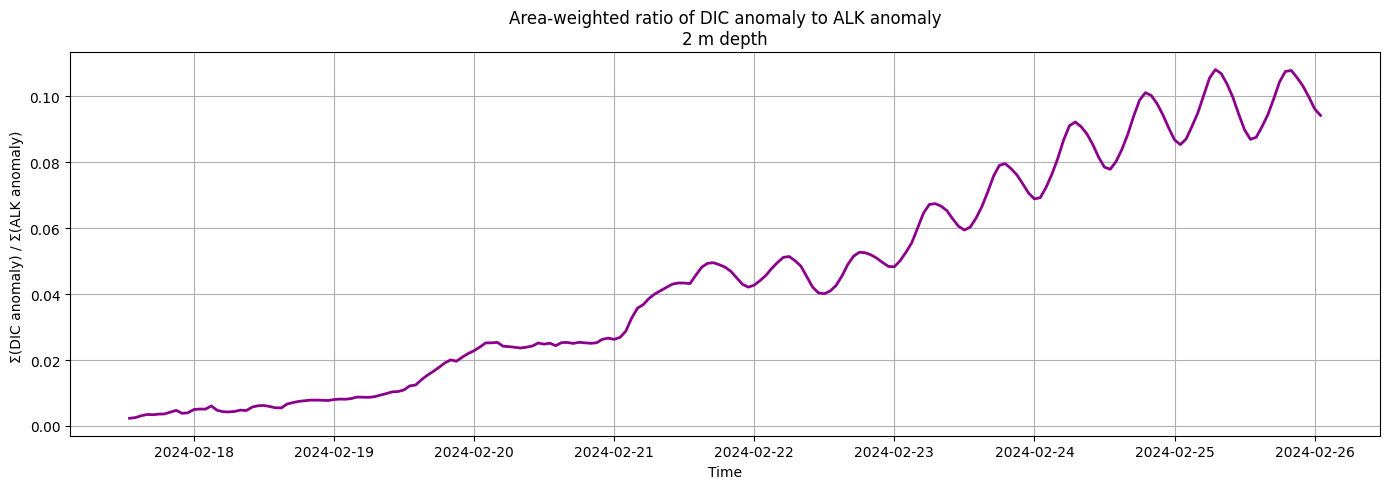

In [35]:
# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    ratio.time,
    ratio,
    color="darkmagenta",
    linewidth=2,
)

plt.title(
    "Area-weighted ratio of DIC anomaly to ALK anomaly\n"
    "2 m depth"
)
plt.xlabel("Time")
plt.ylabel("Σ(DIC anomaly) / Σ(ALK anomaly) ")
plt.grid(True)

plt.tight_layout()
plt.show()


In [36]:
pip install pyco2sys

Note: you may need to restart the kernel to use updated packages.


In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import numpy as np

# Target snapshot
t_snap = np.datetime64("2024-02-21T00:00:00")
depth_target = 2.0

# Select nearest time & depth
ds_snap_dic = ds_dic.sel(
    time=t_snap,
    depth=depth_target,
    method="nearest"
)

ds_snap_alk = ds_alk.sel(
    time=t_snap,
    depth=depth_target,
    method="nearest"
)


In [44]:
ALK_anom = ds_snap_alk["ALK"] - ds_snap_alk["ALK_ALT_CO2"]
DIC_anom = ds_snap_dic["DIC"] - ds_snap_dic["DIC_ALT_CO2"]


/tmp/ipykernel_821739/427480349.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


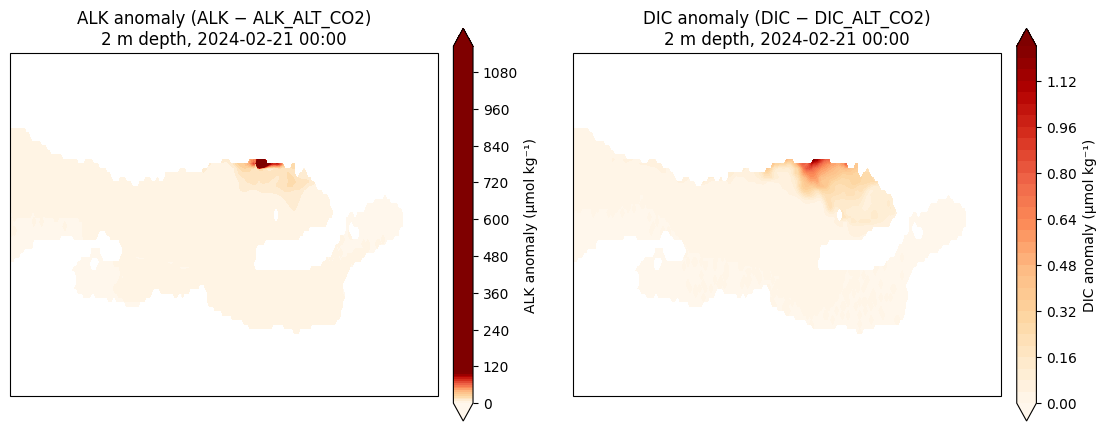

In [46]:
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, wspace=0.08)

extent_upper_hval = [
    -21.6,   # lon min
    -21.37,  # lon max
    64.34,   # lat min
    64.42    # lat max
]
proj = ccrs.Mercator()
data_crs = ccrs.PlateCarree()

# ==========================
# Panel 1 — ALK anomaly
# ==========================
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax1.set_extent(extent_upper_hval, crs=data_crs)

cf1 = ax1.contourf(
    ds_alk["lon"], ds_alk["lat"],
    ALK_anom,
    levels=200,
    cmap="OrRd",vmin=0, vmax=100,
    transform=data_crs,
    extend="both"
)

ax1.set_title("ALK anomaly (ALK − ALK_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
#ax1.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=data_crs)
#ax1.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=data_crs)
ax1.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax1.yaxis.set_major_formatter(cticker.LatitudeFormatter())

cbar1 = fig.colorbar(cf1, ax=ax1, shrink=0.85, pad=0.03)
cbar1.set_label("ALK anomaly (µmol kg⁻¹)")

# ==========================
# Panel 2 — DIC anomaly
# ==========================
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.set_extent(extent_upper_hval, crs=data_crs)

cf2 = ax2.contourf(
    ds_dic["lon"], ds_dic["lat"],
    DIC_anom,
    levels=31,
    cmap="OrRd", 
    transform=data_crs,
    extend="both"
)

ax2.set_title("DIC anomaly (DIC − DIC_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
#ax2.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=data_crs)
#ax2.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=data_crs)
ax2.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax2.yaxis.set_major_formatter(cticker.LatitudeFormatter())

cbar2 = fig.colorbar(cf2, ax=ax2, shrink=0.85, pad=0.03)
cbar2.set_label("DIC anomaly (µmol kg⁻¹)")

plt.tight_layout()
plt.show()


In [47]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# --------------------------------------------------
# User settings
# --------------------------------------------------
depth_target = 2.0   # meters

# --------------------------------------------------
# Select depth
# --------------------------------------------------
ds_2m = ds_alk.sel(depth=depth_target, method="nearest")

# --------------------------------------------------
# Compute anomalies
# --------------------------------------------------
ALK_anom = ds_2m["ALK"] - ds_2m["ALK_ALT_CO2"]
DIC_anom = ds_2m["DIC"] - ds_2m["DIC_ALT_CO2"]

# --------------------------------------------------
# Compute grid-cell area weights (lat/lon grid)
# --------------------------------------------------
R = 6371e3  # Earth radius (m)

lat_rad = np.deg2rad(ds_2m.lat)
lon_rad = np.deg2rad(ds_2m.lon)

dlat = float(np.abs(lat_rad[1] - lat_rad[0]))
dlon = float(np.abs(lon_rad[1] - lon_rad[0]))

cell_area = (
    R**2
    * dlat
    * dlon
    * np.cos(lat_rad)
)

area = xr.DataArray(
    cell_area,
    coords={"lat": ds_2m.lat},
    dims=("lat",)
).broadcast_like(ALK_anom.isel(time=0))

# --------------------------------------------------
# Area-weighted sums
# --------------------------------------------------
ALK_sum = (ALK_anom * area).sum(dim=("lat", "lon"), skipna=True)
DIC_sum = (DIC_anom * area).sum(dim=("lat", "lon"), skipna=True)

# --------------------------------------------------
# Ratio
# --------------------------------------------------
ratio =  DIC_sum / ALK_sum 
ratio = ratio.where(np.isfinite(ratio))

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    ratio.time,
    ratio,
    color="darkmagenta",
    linewidth=2,
)

plt.title(
    "Area-weighted ratio of DIC anomaly to ALK anomaly\n"
    "2 m depth"
)
plt.xlabel("Time")
plt.ylabel("Σ(DIC anomaly) / Σ(ALK anomaly) ")
plt.grid(True)

plt.tight_layout()
plt.show()


KeyError: "No variable named 'DIC'. Variables on the dataset include ['ALK', 'ALK_ALT_CO2', 'time', 'lat', 'lon', 'depth']"

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 0.9],
    hspace=0.25,
    wspace=0.08
)

extent_upper_hval = [-21.6, -21.37, 64.34, 64.42]
proj = ccrs.Mercator()
data_crs = ccrs.PlateCarree()


plot_time = np.datetime64("2024-02-21T00:00")

ALK_map = ALK_anom.sel(time=plot_time)
DIC_map = DIC_anom.sel(time=plot_time)


# ==================================================
# Panel a) — ALK anomaly
# ==================================================
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax1.set_extent(extent_upper_hval, crs=data_crs)

cf1 = ax1.contourf(
    ds_trac["lon"], ds_trac["lat"],
    ALK_map,
    levels=200,
    cmap="OrRd",
    vmin=0, vmax=100,
    transform=data_crs,
    extend="both"
)

ax1.set_title("ALK anomaly (ALK − ALK_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
ax1.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax1.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax1.text(
    0.02, 0.98, "a)",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

cbar1 = fig.colorbar(cf1, ax=ax1, shrink=0.85, pad=0.03)
cbar1.set_label("ALK anomaly (µmol kg⁻¹)")

gl1 = ax1.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {"size": 9}
gl1.ylabel_style = {"size": 9}

# ==================================================
# Panel b) — DIC anomaly
# ==================================================
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.set_extent(extent_upper_hval, crs=data_crs)

cf2 = ax2.contourf(
    ds_trac["lon"], ds_trac["lat"],
    DIC_map,
    levels=31,
    cmap="OrRd",
    transform=data_crs,
    extend="both"
)

ax2.set_title("DIC anomaly (DIC − DIC_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
ax2.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax2.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax2.text(
    0.02, 0.98, "b)",
    transform=ax2.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

cbar2 = fig.colorbar(cf2, ax=ax2, shrink=0.85, pad=0.03)
cbar2.set_label("DIC anomaly (µmol kg⁻¹)")

gl2 = ax2.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = False   # prevents duplicate y-labels between panels
gl2.xlabel_style = {"size": 9}
gl2.ylabel_style = {"size": 9}


# ==================================================
# Panel c) — Ratio time series (spans both columns)
# ==================================================
ax3 = fig.add_subplot(gs[1, :])

ax3.plot(
    ratio.time,
    ratio,
    color="darkmagenta",
    linewidth=2
)

ax3.set_title(
    "Area-weighted ratio of DIC anomaly to ALK anomaly\n2 m depth"
)
ax3.set_xlabel("Time")
ax3.set_ylabel("Σ(DIC anomaly) / Σ(ALK anomaly)")
ax3.grid(True)

ax3.text(
    0.01, 0.95, "c)",
    transform=ax3.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)
t_start = np.datetime64("2024-02-17T18:00")
t_end   = np.datetime64("2024-02-21T18:00")

ax3.axvline(
    t_start,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Experiment duration"
)

ax3.axvline(
    t_end,
    color="black",
    linestyle="--",
    linewidth=1.5
)
ax3.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:

import xarray as xr
import numpy as np
import PyCO2SYS as pyco2

# ==================================================
# USER-SPECIFIED BACKGROUND STATE
# ==================================================
BACKGROUND = dict(
    ALK = 2300.0,     # umol/kg
    DIC = 2150.0,     # umol/kg
    T = 5.0,          # deg C
    S = 35.0,         # PSU
    P = 0.0,          # dbar
    PO4 = 0.0,        # umol/kg
    Si = 0.0          # umol/kg
)

# ==================================================
# Open dataset
# ==================================================
ds = ds_trac

# ==================================================
# Compute alkalinity anomaly
# ==================================================
dALK = ds["ALK"] - ds["ALK_ALT_CO2"]

# (optional) choose surface layer
dALK_surf = dALK.isel(depth=0)

# ==================================================
# Collapse to maximum anomaly in space & time
# (worst-case pH excursion)
# ==================================================
dALK_max = float(dALK.max(skipna=True))

print(f"Maximum alkalinity anomaly: {dALK_max:.2f} µmol/kg")

# ==================================================
# Carbonate chemistry: background pH
# ==================================================
bg = pyco2.sys(
    par1=BACKGROUND["ALK"],
    par2=BACKGROUND["DIC"],
    par1_type=1,      # ALK
    par2_type=2,      # DIC
    salinity=BACKGROUND["S"],
    temperature=BACKGROUND["T"],
    pressure=BACKGROUND["P"],
    total_phosphate=BACKGROUND["PO4"],
    total_silicate=BACKGROUND["Si"]
)

pH_bg = bg["pH_total"]

# ==================================================
# Perturbed state (ALK + anomaly)
# ==================================================
pert = pyco2.sys(
    par1=BACKGROUND["ALK"] + dALK_max,
    par2=BACKGROUND["DIC"],
    par1_type=1,
    par2_type=2,
    salinity=BACKGROUND["S"],
    temperature=BACKGROUND["T"],
    pressure=BACKGROUND["P"],
    total_phosphate=BACKGROUND["PO4"],
    total_silicate=BACKGROUND["Si"]
)

pH_pert = pert["pH_total"]

# ==================================================
# pH excursion
# ==================================================
dpH = pH_pert - pH_bg

print("\n===== RESULTS =====")
print(f"Background pH        : {pH_bg:.4f}")
print(f"Perturbed pH         : {pH_pert:.4f}")
print(f"Maximum ΔpH excursion: {dpH:+.4f}")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PyCO2SYS as pyco2

# ==================================================
# USER CONSTANTS
# ==================================================
T = 5.0        # deg C
S = 34.5       # PSU
P = 0.0        # dbar
PO4 = 0.9
Si = 7.6

# ==================================================
# Background phase space
# ==================================================
ALK_vals = np.linspace(2250, 2350, 10)   # µmol/kg
DIC_vals = np.linspace(2000, 2200, 10)   # µmol/kg

# ==================================================
# Dataset + maximum alkalinity anomaly
# ==================================================
ds = ds_trac
dALK = ds["ALK"] - ds["ALK_ALT_CO2"]
dALK_max = float(dALK.max(skipna=True))

print(f"Using maximum ALK anomaly: {dALK_max:.2f} µmol/kg")

# ==================================================
# ==================================================
dpH_max = np.zeros((len(ALK_vals), len(DIC_vals)))

# ==================================================
# Loop over background ALK–DIC phase space
# ==================================================
for i, ALK_bg in enumerate(ALK_vals):
    for j, DIC_bg in enumerate(DIC_vals):

        # ---------- Background pH ----------
        bg = pyco2.sys(
            par1=ALK_bg,
            par2=DIC_bg,
            par1_type=1,      # ALK
            par2_type=2,      # DIC
            salinity=S,
            temperature=T,
            pressure=P,
            total_phosphate=PO4,
            total_silicate=Si
        )

        # ---------- Perturbed pH (ALK + max anomaly) ----------
        pert = pyco2.sys(
            par1=ALK_bg + dALK_max,
            par2=DIC_bg,
            par1_type=1,
            par2_type=2,
            salinity=S,
            temperature=T,
            pressure=P,
            total_phosphate=PO4,
            total_silicate=Si
        )

        dpH_max[i, j] = pert["pH_total"]

# ==================================================
# Phase-space contour plot
# ==================================================
DIC_grid, ALK_grid = np.meshgrid(DIC_vals, ALK_vals)

plt.figure(figsize=(7, 5), dpi=300)

cs = plt.contourf(
    DIC_grid,
    ALK_grid,
    dpH_max,
    levels=20,
    cmap="viridis"
)

cbar = plt.colorbar(cs)
cbar.set_label("Maximum ΔpH")
# ==================================================
# Overlay observed and modeled points
# ==================================================

# Observed values
ALK_obs = 2345
DIC_obs = 2145

# Modeled values
ALK_mod = 2280
DIC_mod = 2100

# Plot points
plt.plot(
    DIC_obs, ALK_obs,
    marker='o',
    markersize=8,
    markeredgecolor='k',
    markerfacecolor='white',
    linestyle='none',
    label='Observed'
)

plt.plot(
    DIC_mod, ALK_mod,
    marker='^',
    markersize=8,
    markeredgecolor='k',
    markerfacecolor='red',
    linestyle='none',
    label='Modeled'
)

# Optional text labels (comment out if too busy)
plt.text(DIC_obs + 3, ALK_obs + 3, 'Observed', fontsize=8)
plt.text(DIC_mod + 3, ALK_mod + 3, 'Modeled', fontsize=8)

# Ensure legend shows points
#plt.legend(frameon=True)


plt.xlabel("Background DIC (µmol kg⁻¹)")
plt.ylabel("Background Alkalinity (µmol kg⁻¹)")
plt.title("Maximum pH Excursion from Maximum ALK Anomaly")

plt.tight_layout()
plt.show()
